In [1]:
import pandas as pd

df = pd.read_excel(r"C:\Users\piuze\DAMO-500-15 Principles of Data Analytics\Week 8\Take_Home Assignment dataset.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  600 non-null    int64  
 1   Training_Group      600 non-null    object 
 2   Department          600 non-null    object 
 3   Region              600 non-null    object 
 4   Gender              600 non-null    object 
 5   Promotion_Exposure  600 non-null    object 
 6   Purchase_Converted  600 non-null    int64  
 7   Age                 600 non-null    int64  
 8   Annual_Income       600 non-null    int64  
 9   Engagement_Minutes  600 non-null    float64
 10  Monthly_Spend       600 non-null    float64
 11  Satisfaction_1to10  600 non-null    float64
 12  Performance_Score   600 non-null    float64
 13  Returns_Count       600 non-null    int64  
dtypes: float64(4), int64(5), object(5)
memory usage: 65.8+ KB


In [2]:
df.head()

,ID,Training_Group,Department,Region,Gender,Promotion_Exposure,Purchase_Converted,Age,Annual_Income,Engagement_Minutes,Monthly_Spend,Satisfaction_1to10,Performance_Score,Returns_Count
0,1,Treatment_C,Retail,Alberta,Male,Yes,0,18,173313,122.7,866.98,6.5,75.6,3
1,2,Treatment_A,Online,Quebec,Female,Yes,0,37,68631,172.6,749.26,4.8,85.5,4
2,3,Treatment_C,Retail,Ontario,Other,Yes,0,36,55214,487.1,3025.40,5.0,89.5,3
3,4,Treatment_C,Retail,Alberta,Other,Yes,1,32,202616,28.2,1058.99,6.4,79.9,4
4,5,Treatment_B,Retail,Quebec,Female,Yes,1,32,115110,304.1,1730.38,7.4,79.8,2


In [3]:
df["Satisfaction_1to10"].value_counts()

Satisfaction_1to10
6.8    22
6.3    22
7.4    21
6.0    21
7.5    20
       ..
2.3     1
9.7     1
2.7     1
9.9     1
3.3     1
Name: count, Length: 73, dtype: int64

In [4]:
df.shape

(600, 14)

In [5]:
df["Returns_Count"].value_counts()

Returns_Count
2     119
3     104
1     102
4      89
5      50
0      42
6      35
7      22
8      15
9       9
11      5
10      4
14      2
16      1
13      1
Name: count, dtype: int64

# BEFORE Table (Descriptive Statistics)

In [7]:
import pandas as pd

def before_table_with_fivenum(df, columns):
    """
    Creates a descriptive statistics table including:
    Mean, SD, Min, Q1, Median, Q3, Max
    for the variables listed in 'columns'.
    """
    results = []

    for col in columns:
        series = df[col].dropna()

        results.append({
            "Variable": col,
            "Mean": round(series.mean(), 3),
            "SD": round(series.std(), 3),
            "Min": round(series.min(), 3),
            "Q1": round(series.quantile(0.25), 3),
            "Median": round(series.median(), 3),
            "Q3": round(series.quantile(0.75), 3),
            "Max": round(series.max(), 3)
        })

    return pd.DataFrame(results)

# Example usage:
columns_to_check = ["Age", "Annual_Income","Engagement_Minutes", "Monthly_Spend", "Satisfaction_1to10", "Performance_Score"]
before_stats = before_table_with_fivenum(df, columns_to_check)
before_stats


,Variable,Mean,SD,Min,Q1,Median,Q3,Max
0,Age,39.200,11.509,18.00,31.750,39.00,47.000,70.00
1,Annual_Income,68659.835,38883.256,18000.00,40295.000,58897.00,84965.750,250000.00
2,Engagement_Minutes,146.578,113.549,19.50,78.875,117.25,168.000,1200.00
3,Monthly_Spend,1083.862,868.279,139.25,532.475,817.88,1375.502,7432.88
4,Satisfaction_1to10,6.719,1.510,2.30,5.700,6.80,7.800,10.00
5,Performance_Score,77.119,9.346,33.10,71.000,77.50,83.575,100.00


# IQR‑Based Outlier Detection

In [9]:
import pandas as pd

def iqr_outlier_summary(df, columns):
    results = []

    for col in columns:
        series = df[col].dropna()

        # Five-number summary
        minimum = series.min()
        q1 = series.quantile(0.25)
        median = series.median()
        q3 = series.quantile(0.75)
        maximum = series.max()

        # IQR and bounds
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Outlier detection
        outliers = series[(series < lower_bound) | (series > upper_bound)]
        outlier_pct = (len(outliers) / len(series)) * 100

        # Decision rule
        decision = "Keep (outliers < 5%)" if outlier_pct < 5 else "Consider removal (> 5%)"

        results.append({
            "Variable": col,
            "Min": minimum,
            "Q1": q1,
            "Median": median,
            "Q3": q3,
            "Max": maximum,
            "IQR": iqr,
            "Lower_Bound": lower_bound,
            "Upper_Bound": upper_bound,
            "Outlier_%": round(outlier_pct, 2),
            "Decision": decision
        })

    return pd.DataFrame(results)

# Example usage:
columns_to_check = ["Age", "Annual_Income","Engagement_Minutes", "Monthly_Spend", "Satisfaction_1to10", "Performance_Score"]
iqr_results = iqr_outlier_summary(df, columns_to_check)
iqr_results


,Variable,Min,Q1,Median,Q3,Max,IQR,Lower_Bound,Upper_Bound,Outlier_%,Decision
0,Age,18.00,31.750,39.00,47.0000,70.00,15.2500,8.87500,69.87500,0.33,Keep (outliers < 5%)
1,Annual_Income,18000.00,40295.000,58897.00,84965.7500,250000.00,44670.7500,-26711.12500,151971.87500,5.00,Consider removal (> 5%)
2,Engagement_Minutes,19.50,78.875,117.25,168.0000,1200.00,89.1250,-54.81250,301.68750,7.50,Consider removal (> 5%)
3,Monthly_Spend,139.25,532.475,817.88,1375.5025,7432.88,843.0275,-732.06625,2640.04375,5.83,Consider removal (> 5%)
4,Satisfaction_1to10,2.30,5.700,6.80,7.8000,10.00,2.1000,2.55000,10.95000,0.67,Keep (outliers < 5%)
5,Performance_Score,33.10,71.000,77.50,83.5750,100.00,12.5750,52.13750,102.43750,0.67,Keep (outliers < 5%)


In [10]:
iqr_results[["Variable", "IQR", "Lower_Bound", "Upper_Bound", "Outlier_%","Decision"]]

,Variable,IQR,Lower_Bound,Upper_Bound,Outlier_%,Decision
0,Age,15.2500,8.87500,69.87500,0.33,Keep (outliers < 5%)
1,Annual_Income,44670.7500,-26711.12500,151971.87500,5.00,Consider removal (> 5%)
2,Engagement_Minutes,89.1250,-54.81250,301.68750,7.50,Consider removal (> 5%)
3,Monthly_Spend,843.0275,-732.06625,2640.04375,5.83,Consider removal (> 5%)
4,Satisfaction_1to10,2.1000,2.55000,10.95000,0.67,Keep (outliers < 5%)
5,Performance_Score,12.5750,52.13750,102.43750,0.67,Keep (outliers < 5%)


# Z‑Score Outlier Detection

In [12]:
import pandas as pd
import numpy as np

def zscore_outlier_summary(df, columns):
    results = []

    for col in columns:
        series = df[col].dropna()

        # Mean and SD
        mean = series.mean()
        std = series.std()

        # Z-scores
        zscores = (series - mean) / std

        # Outliers: |Z| > 3
        outliers = zscores[zscores.abs() > 3]
        outlier_pct = (len(outliers) / len(series)) * 100

        # Decision rule
        decision = "Keep (outliers < 5%)" if outlier_pct < 5 else "Consider removal (> 5%)"

        results.append({
            "Variable": col,
            "Mean": mean,
            "SD": std,
            "Lower_Z": -3,
            "Upper_Z": 3,
            "Outlier_%": round(outlier_pct, 2),
            "Decision": decision
        })

    return pd.DataFrame(results)

# Example usage:
columns_to_check = ["Age", "Annual_Income","Engagement_Minutes", "Monthly_Spend", "Satisfaction_1to10", "Performance_Score"]
zscore_results = zscore_outlier_summary(df, columns_to_check)
zscore_results


,Variable,Mean,SD,Lower_Z,Upper_Z,Outlier_%,Decision
0,Age,39.200000,11.509305,-3,3,0.00,Keep (outliers < 5%)
1,Annual_Income,68659.835000,38883.256331,-3,3,1.33,Keep (outliers < 5%)
2,Engagement_Minutes,146.578500,113.549320,-3,3,2.17,Keep (outliers < 5%)
3,Monthly_Spend,1083.861750,868.279372,-3,3,2.17,Keep (outliers < 5%)
4,Satisfaction_1to10,6.718833,1.509833,-3,3,0.00,Keep (outliers < 5%)
5,Performance_Score,77.119000,9.346220,-3,3,0.67,Keep (outliers < 5%)


# Visualizations 

In [14]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis, mode

def descriptive_table(df, columns):
    """
    Creates a descriptive statistics table including:
    Mean, Median, Mode, SD, Skewness, Kurtosis,
    Min, Q1, Median, Q3, Max
    """
    results = []

    for col in columns:
        series = df[col].dropna()

        # Mode returns an array; take the first value
        mode_value = mode(series, keepdims=True).mode[0]

        results.append({
            "Variable": col,
            "Mean": round(series.mean(), 3),
            "Median": round(series.median(), 3),
            "Mode": round(mode_value, 3),
            "SD": round(series.std(), 3),
            "Skewness": round(skew(series), 3),
            "Kurtosis": round(kurtosis(series), 3),
            "Min": round(series.min(), 3),
            "Q1": round(series.quantile(0.25), 3),
            "Q2": round(series.median(), 3),
            "Q3": round(series.quantile(0.75), 3),
            "Max": round(series.max(), 3)
        })

    return pd.DataFrame(results)

# Example usage:
columns_to_check = ["Engagement_Minutes", "Monthly_Spend", "Satisfaction_1to10", "Performance_Score"]
table_31 = descriptive_table(df, columns_to_check)
table_31


,Variable,Mean,Median,Mode,SD,Skewness,Kurtosis,Min,Q1,Q2,Q3,Max
0,Engagement_Minutes,146.578,117.25,46.40,113.549,3.174,17.090,19.50,78.875,117.25,168.000,1200.00
1,Monthly_Spend,1083.862,817.88,469.88,868.279,2.408,8.879,139.25,532.475,817.88,1375.502,7432.88
2,Satisfaction_1to10,6.719,6.80,6.30,1.510,-0.195,-0.206,2.30,5.700,6.80,7.800,10.00
3,Performance_Score,77.119,77.50,78.60,9.346,-0.399,1.141,33.10,71.000,77.50,83.575,100.00


# Visualizations 

# Bar Chart of Gender (Categorical Variable)

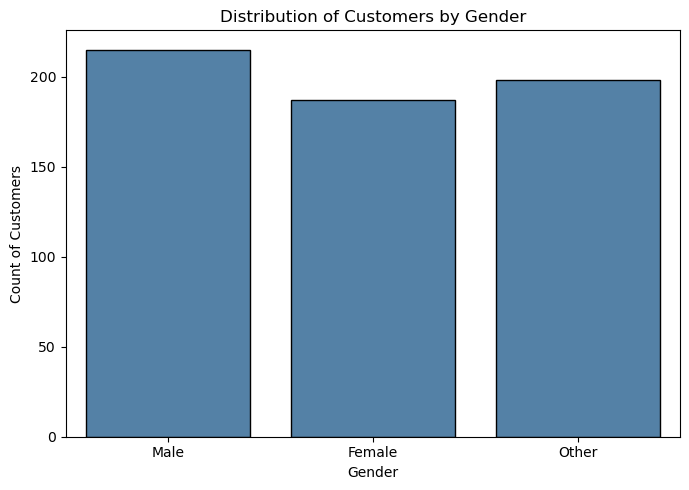

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Gender", color="steelblue", edgecolor="black")

plt.title("Distribution of Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Count of Customers")

plt.tight_layout()
plt.show()


In [18]:
df['Gender'].value_counts()

Gender
Male      215
Other     198
Female    187
Name: count, dtype: int64

# Histogram of Monthly Spend (Numerical Variable)

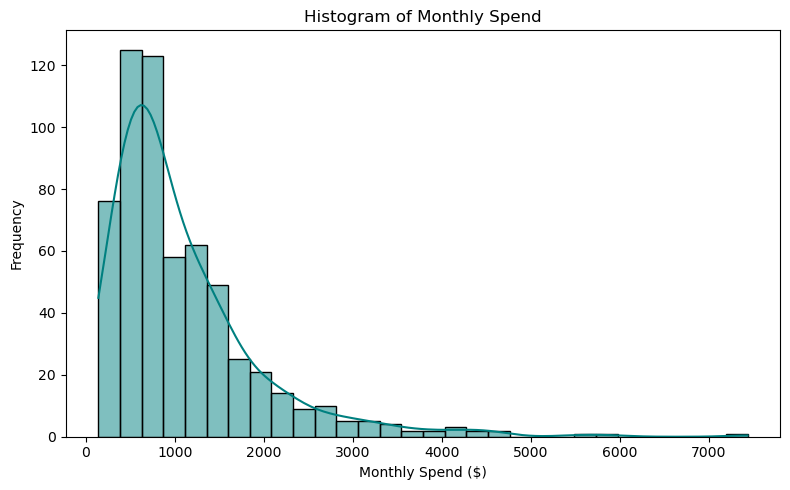

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Monthly_Spend", bins=30, kde=True,
             color="teal", edgecolor="black")

plt.title("Histogram of Monthly Spend")
plt.xlabel("Monthly Spend ($)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Scatterplot of Engagement Minutes vs. Performance Score

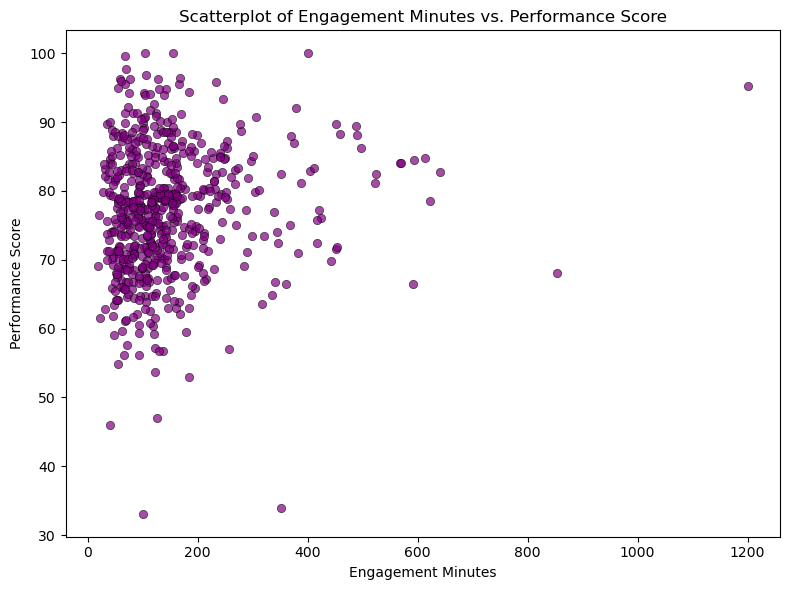

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Engagement_Minutes", y="Performance_Score",
                color="purple", edgecolor="black", alpha=0.7)

plt.title("Scatterplot of Engagement Minutes vs. Performance Score")
plt.xlabel("Engagement Minutes")
plt.ylabel("Performance Score")

plt.tight_layout()
plt.show()


# Boxplot of Monthly Spend by Department (Multivariate Visualization)

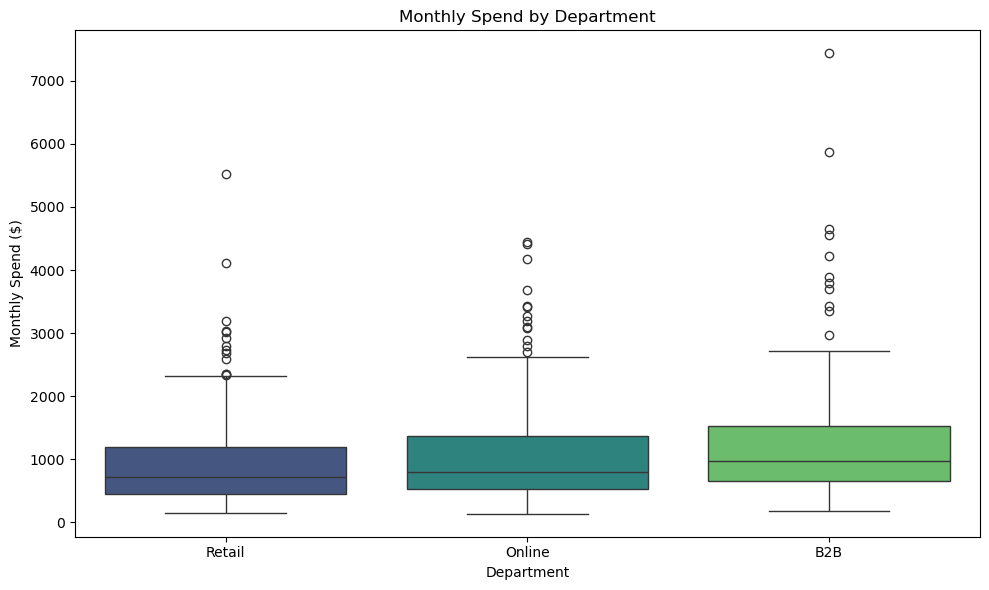

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="Department",
    y="Monthly_Spend",
    hue="Department",          # NEW: assign hue to match palette
    palette="viridis",
    legend=False               # NEW: hide duplicate legend
)

plt.title("Monthly Spend by Department")
plt.xlabel("Department")
plt.ylabel("Monthly Spend ($)")

plt.tight_layout()
plt.show()


In [25]:
df['Department'].value_counts()

Department
Online    211
Retail    207
B2B       182
Name: count, dtype: int64

# Correlation Analysis: Engagement Minutes vs. Performance Score

## Test Normality (Shapiro–Wilk)

In [28]:
from scipy.stats import shapiro
import pandas as pd


x = df["Engagement_Minutes"]
y = df["Performance_Score"]

# Shapiro–Wilk normality tests
shapiro_x = shapiro(x)
shapiro_y = shapiro(y)

print("Engagement_Minutes Shapiro:", shapiro_x)
print("Performance_Score Shapiro:", shapiro_y)


Engagement_Minutes Shapiro: ShapiroResult(statistic=0.7296016614511633, pvalue=4.688182020051613e-30)
Performance_Score Shapiro: ShapiroResult(statistic=0.9860782624356959, pvalue=1.7322056207656254e-05)


## Spearman Correlation

In [30]:
import pandas as pd
from scipy.stats import spearmanr


# Select variables
x = df["Engagement_Minutes"]
y = df["Performance_Score"]

# Spearman correlation
rho, p_value = spearmanr(x, y)

print("Spearman correlation (rho):", rho)
print("p-value:", p_value)


Spearman correlation (rho): 0.13373089699379268
p-value: 0.0010247057526675942


## Chi‑Square Test + Cramer’s V

In [32]:
import pandas as pd
import scipy.stats as stats
import numpy as np


# Choose categorical variables
cat1 = df["Promotion_Exposure"]
cat2 = df["Purchase_Converted"]

# Contingency table
table = pd.crosstab(cat1, cat2)

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(table)

# Cramer's V
n = table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

print("Contingency Table:\n", table)
print("\nChi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", cramers_v)
print("\nExpected counts:\n", expected)


Contingency Table:
 Purchase_Converted    0    1
Promotion_Exposure          
No                  181   72
Yes                 220  127

Chi-square statistic: 4.015174838403405
Degrees of freedom: 1
p-value: 0.04509254781283398
Cramer's V: 0.08180438902654108

Expected counts:
 [[169.08833333  83.91166667]
 [231.91166667 115.08833333]]


# ANOVA test

## Shapiro–Wilk Normality Test for Each Department

In [35]:
import pandas as pd
from scipy.stats import shapiro


departments = df["Department"].unique()

for dept in departments:
    group = df[df["Department"] == dept]["Monthly_Spend"]
    stat, p = shapiro(group)
    print(f"{dept} → Shapiro statistic = {stat:.4f}, p-value = {p:.6f}")


Retail → Shapiro statistic = 0.7931, p-value = 0.000000
Online → Shapiro statistic = 0.8209, p-value = 0.000000
B2B → Shapiro statistic = 0.7612, p-value = 0.000000


## Levene’s Test

In [37]:
from scipy.stats import levene

retail = df[df["Department"] == "Retail"]["Monthly_Spend"]
online = df[df["Department"] == "Online"]["Monthly_Spend"]
b2b = df[df["Department"] == "B2B"]["Monthly_Spend"]

lev_stat, lev_p = levene(retail, online, b2b)
print("Levene’s test:", lev_stat, lev_p)


Levene’s test: 2.1850402627903756 0.11337189526864755


## One‑Way ANOVA (if assumptions OK)

In [39]:
from scipy.stats import f_oneway

f_stat, p_val = f_oneway(retail, online, b2b)
print("ANOVA F-statistic:", f_stat)
print("ANOVA p-value:", p_val)


ANOVA F-statistic: 7.0830018642021715
ANOVA p-value: 0.0009116330821232254


## Residual Normality Check

In [41]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import shapiro

# ANOVA model using formula
model = smf.ols("Monthly_Spend ~ C(Department)", data=df).fit()

# Residuals
residuals = model.resid

# Shapiro test on residuals
stat, p = shapiro(residuals)
print("Residual normality (Shapiro):", stat, p)


Residual normality (Shapiro): 0.7933762662943347 6.479787862110207e-27


## ANOVA (only if assumptions OK)

In [43]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

anova_model = smf.ols("Monthly_Spend ~ C(Department)", data=df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print(anova_table)


                     sum_sq     df         F    PR(>F)
C(Department)  1.046728e+07    2.0  7.083002  0.000912
Residual       4.411242e+08  597.0       NaN       NaN


## Residual Normality (the real ANOVA assumption)

In [45]:
residuals = anova_model.resid
stat, p = shapiro(residuals)
print("Residual normality:", stat, p)


Residual normality: 0.7933762662943347 6.479787862110207e-27


## Kruskal–Wallis (if assumptions violated)

In [47]:
from scipy.stats import kruskal

h_stat, p_kw = kruskal(retail, online, b2b)
print("Kruskal–Wallis:", h_stat, p_kw)


Kruskal–Wallis: 19.09682500942895 7.131438450246086e-05


# Simple Python snippet to generate the visualization

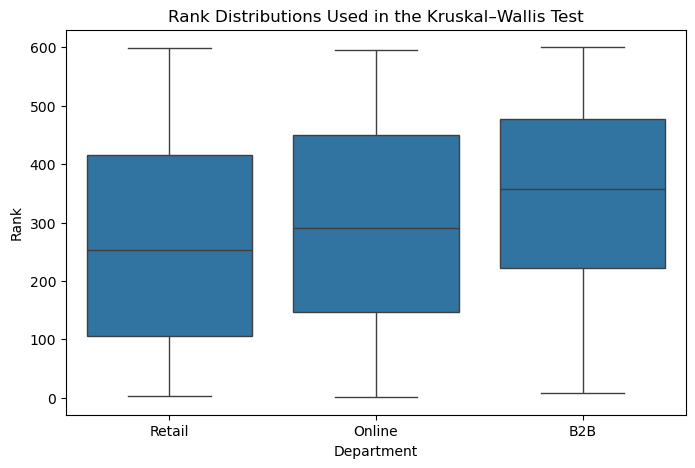

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example: rank transformation
df['Rank'] = df['Monthly_Spend'].rank()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Department', y='Rank')
plt.title("Rank Distributions Used in the Kruskal–Wallis Test")
plt.show()


# Raw vs. Ranked Comparison Plot

This is a beautiful way to show why ANOVA fails and why Kruskal–Wallis works.

Two side‑by‑side boxplots
Left: Raw Monthly Spend (skewed, outliers)

Right: Ranked Monthly Spend (more uniform, less skewed)

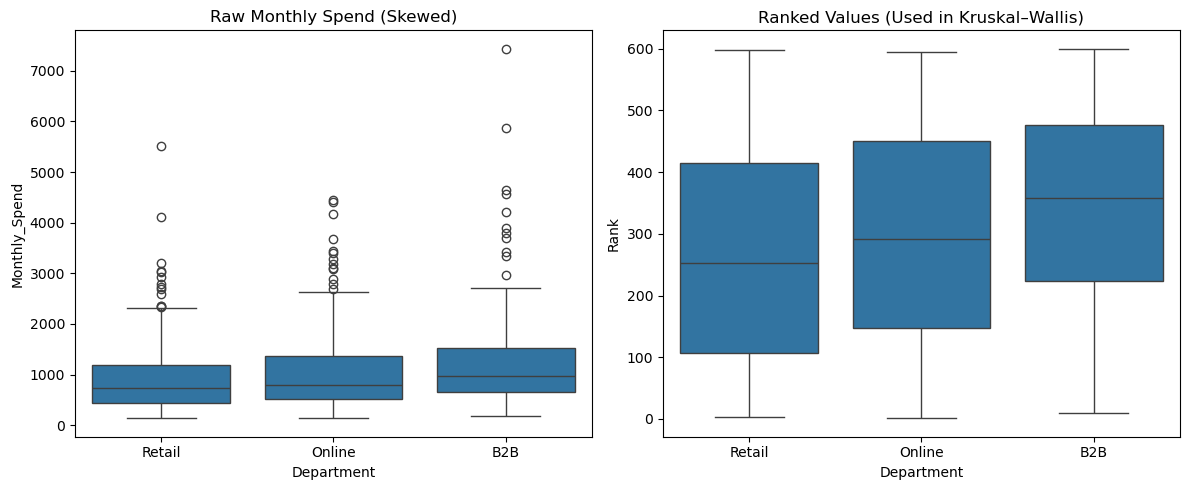

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=df, x='Department', y='Monthly_Spend', ax=axes[0])
axes[0].set_title("Raw Monthly Spend (Skewed)")

sns.boxplot(data=df, x='Department', y='Rank', ax=axes[1])
axes[1].set_title("Ranked Values (Used in Kruskal–Wallis)")

plt.tight_layout()
plt.show()


# 3. ECDF Plots (Non‑parametric friendly)

ECDF = Empirical Cumulative Distribution Function
Perfect for showing distribution differences without assuming normality.

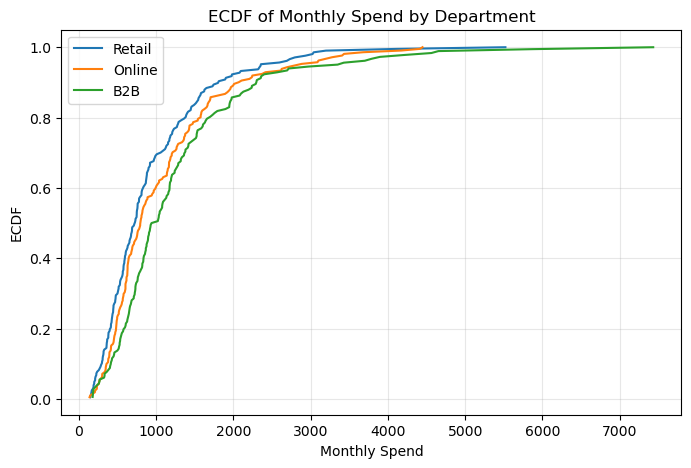

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

plt.figure(figsize=(8,5))

for dept in df['Department'].unique():
    data = df[df['Department'] == dept]['Monthly_Spend']
    ecdf = ECDF(data)
    plt.plot(ecdf.x, ecdf.y, label=dept)

plt.title("ECDF of Monthly Spend by Department")
plt.xlabel("Monthly Spend")
plt.ylabel("ECDF")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


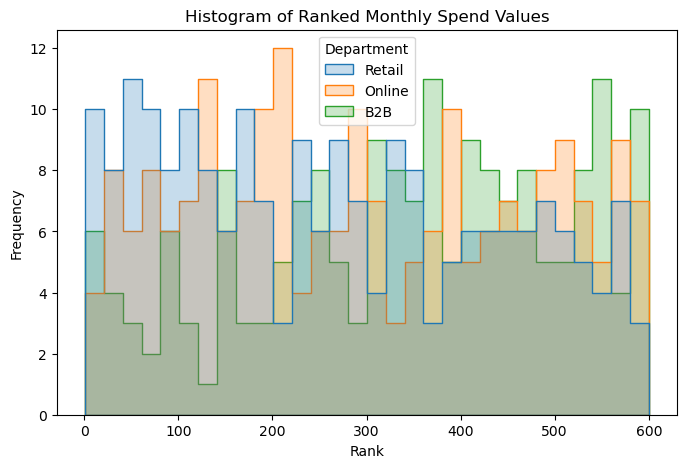

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Rank'] = df['Monthly_Spend'].rank()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Rank', hue='Department', kde=False, bins=30, element='step')
plt.title("Histogram of Ranked Monthly Spend Values")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.show()


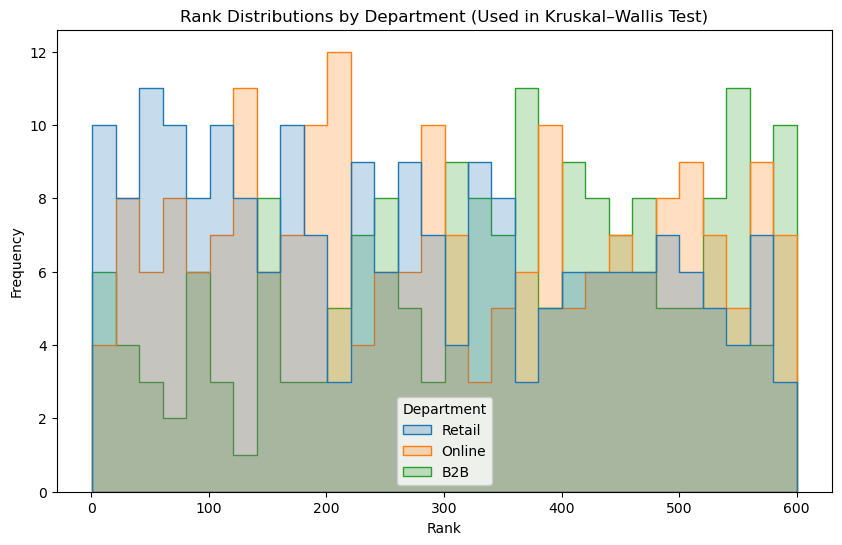

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create ranks across the entire dataset
df['Rank'] = df['Monthly_Spend'].rank()

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Rank',
    hue='Department',
    element='step',
    bins=30,
    kde=False,
    multiple='layer'
)

plt.title("Rank Distributions by Department (Used in Kruskal–Wallis Test)")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.show()


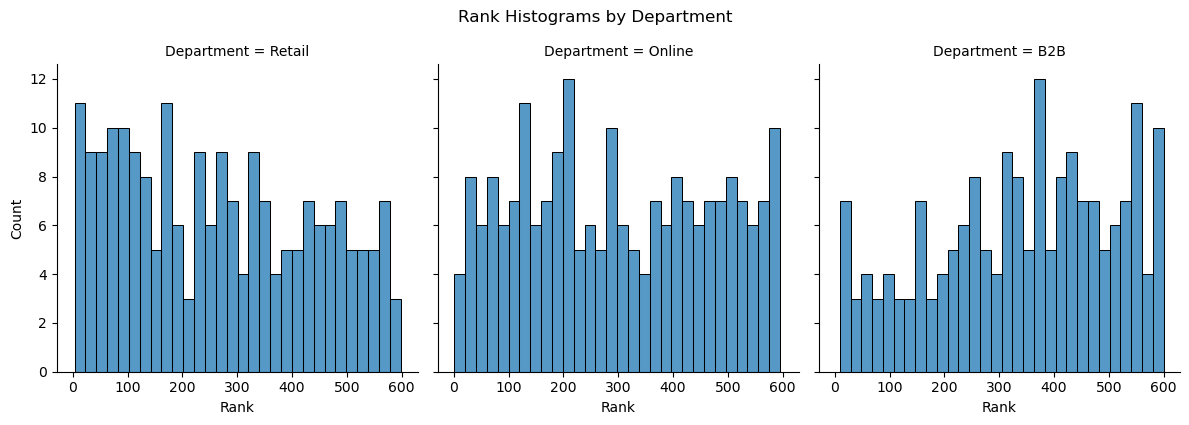

In [91]:
g = sns.FacetGrid(df, col="Department", col_wrap=3, height=4, sharex=True, sharey=True)
g.map(sns.histplot, "Rank", bins=30, kde=False)
g.fig.suptitle("Rank Histograms by Department", y=1.05)
plt.show()


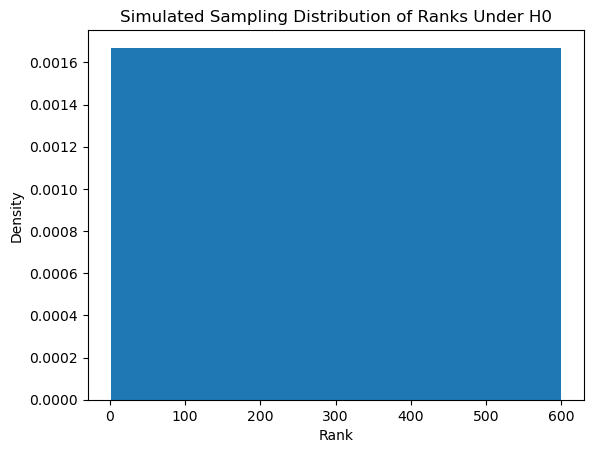

In [93]:
import numpy as np
import matplotlib.pyplot as plt

n = len(df)

simulated_ranks = []

for _ in range(10000):
    sample = np.random.rand(n)
    ranks = sample.argsort().argsort() + 1
    simulated_ranks.extend(ranks)

plt.hist(simulated_ranks, bins=n, density=True)
plt.title("Simulated Sampling Distribution of Ranks Under H0")
plt.xlabel("Rank")
plt.ylabel("Density")
plt.show()


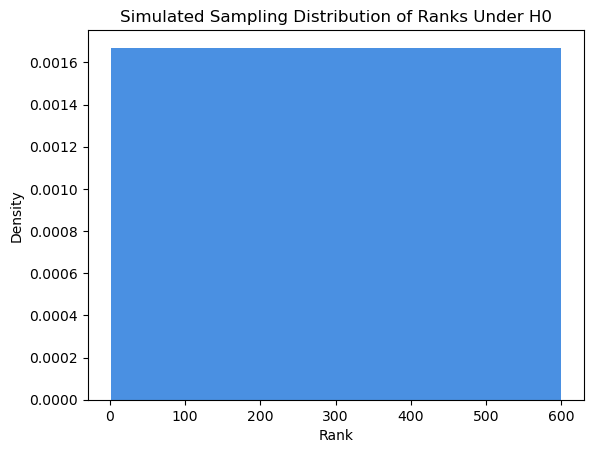

In [95]:
import numpy as np
import matplotlib.pyplot as plt

n = len(df)
simulated_ranks = []

for _ in range(10000):
    sample = np.random.rand(n)
    ranks = sample.argsort().argsort() + 1
    simulated_ranks.extend(ranks)

plt.hist(simulated_ranks, bins=n, density=True, color="#4A90E2")
plt.title("Simulated Sampling Distribution of Ranks Under H0")
plt.xlabel("Rank")
plt.ylabel("Density")
plt.show()


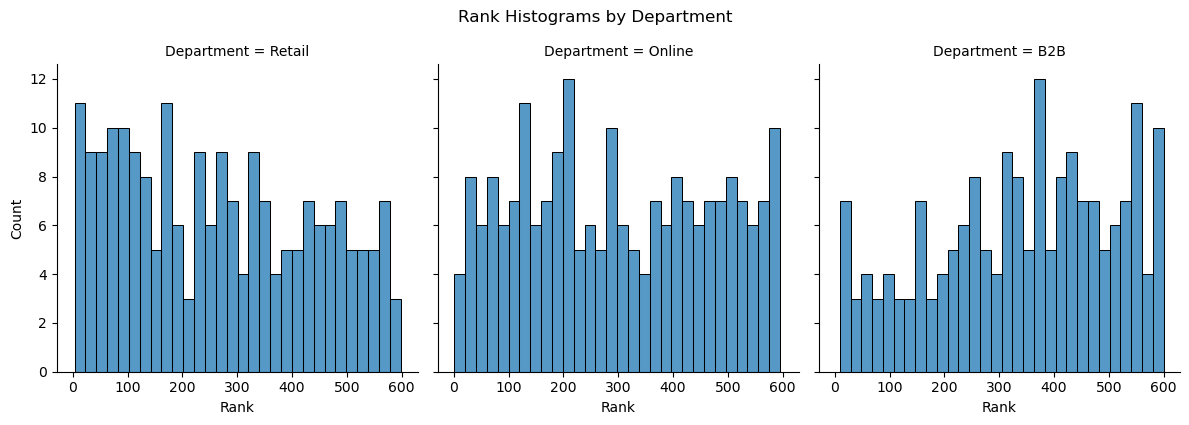

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Rank'] = df['Monthly_Spend'].rank()

g = sns.FacetGrid(df, col="Department", col_wrap=3, height=4, sharex=True, sharey=True)
g.map(sns.histplot, "Rank", bins=30, kde=False)
g.fig.suptitle("Rank Histograms by Department", y=1.05)
plt.show()


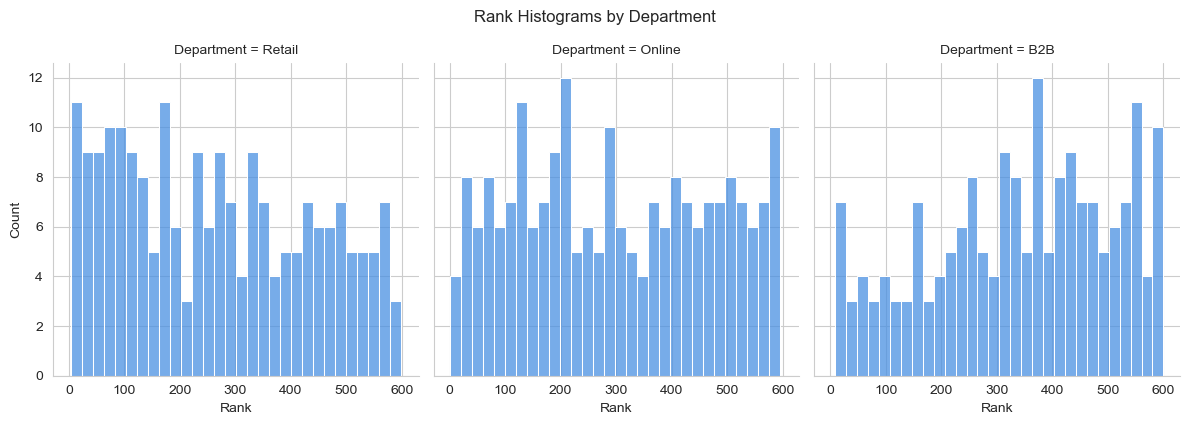

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

# Apply a clean Seaborn style
sns.set_style("whitegrid")

# Create pooled ranks
df['Rank'] = df['Monthly_Spend'].rank()

# Use a nicer color palette
palette = ["#4A90E2", "#2AA198", "#8E44AD"]  # blue, teal, purple

g = sns.FacetGrid(
    df,
    col="Department",
    col_wrap=3,
    height=4,
    sharex=True,
    sharey=True,
    palette=palette
)

g.map(
    sns.histplot,
    "Rank",
    bins=30,
    kde=False,
    color="#4A90E2",   # choose one color or remove to let palette apply
    alpha=0.75         # softer transparency
)

g.fig.suptitle("Rank Histograms by Department", y=1.05)
plt.show()


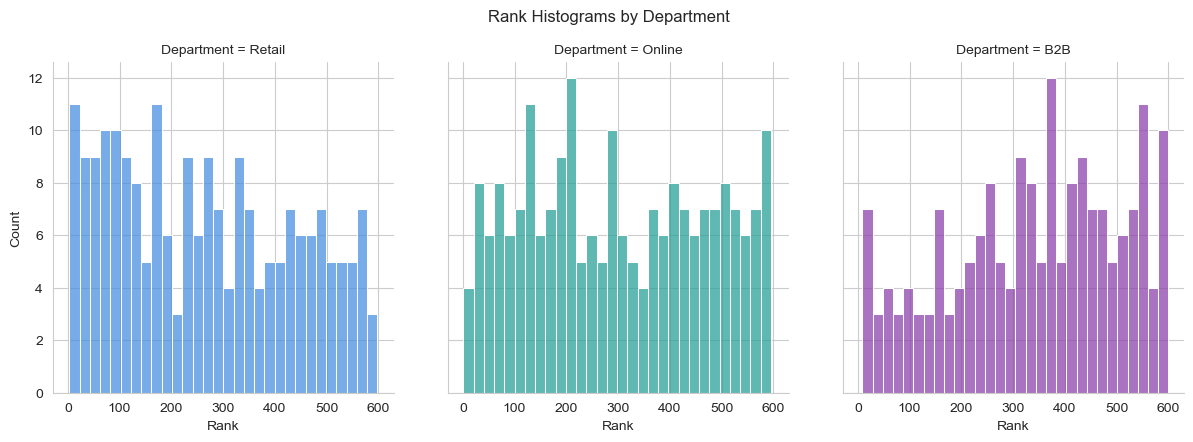

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Create pooled ranks
df['Rank'] = df['Monthly_Spend'].rank()

# Custom colors for each facet (Retail, Online, B2B)
facet_colors = ["#4A90E2", "#2AA198", "#8E44AD"]  # blue, teal, purple

g = sns.FacetGrid(
    df,
    col="Department",
    col_wrap=3,
    height=4,
    sharex=True,
    sharey=True
)

# Apply a different color to each facet
for ax, color in zip(g.axes.flat, facet_colors):
    sns.histplot(
        df[df["Department"] == ax.get_title().split(" = ")[1]]["Rank"],
        bins=30,
        kde=False,
        color=color,
        alpha=0.75,
        ax=ax
    )

g.fig.suptitle("Rank Histograms by Department", y=1.05)
plt.show()
